In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [9]:
df_US = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

In [12]:
job_title = df_US['job_title_short'].value_counts().index[:6].tolist()

job_title


['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [14]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_title)]

job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

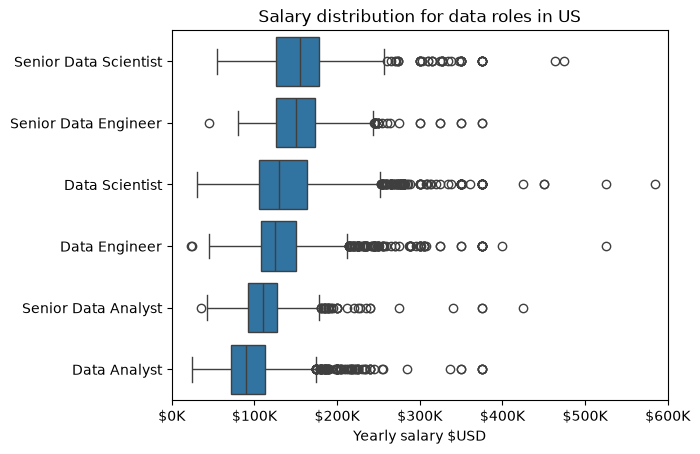

In [16]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short',order=job_order)
plt.title('Salary distribution for data roles in US')
plt.xlabel('Yearly salary $USD')
plt.ylabel('')

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))

plt.xlim(0,600000)
plt.show()

In [18]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [19]:
df_DA_US = df_DA_US.explode('job_skills')

In [21]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median', ascending=False).head(10)

df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [32]:
df_DA_top_skill = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False).head(10)

df_DA_top_skill = df_DA_top_skill.sort_values(by='median', ascending=False)

df_DA_top_skill

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


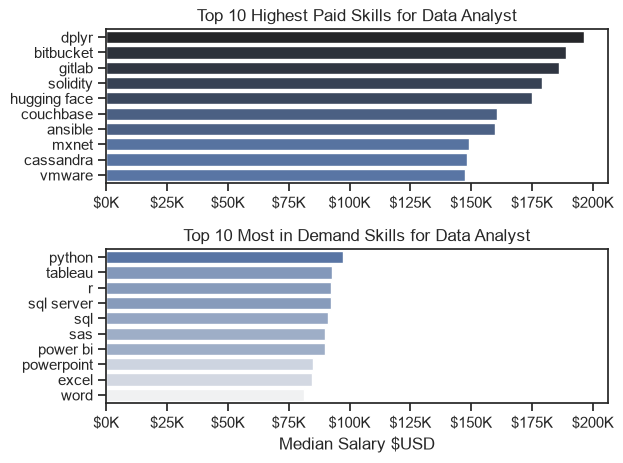

In [35]:
fig, ax = plt.subplots(2,1)
sns.set_theme(style='ticks')

sns.barplot(data=df_DA_top_pay, x='median',y=df_DA_top_pay.index, ax=ax[0],hue='median',palette='dark:b_r')
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0])         #[::-1] same as ax[0].invert_yaxis
ax[0].set_title('Top 10 Highest Paid Skills for Data Analyst')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[0].legend().set_visible(False)

sns.barplot(data=df_DA_top_skill, x='median',y=df_DA_top_skill.index, ax=ax[1], hue='median',palette='light:b')
# df_DA_top_skill[::-1].plot(kind='barh', y='median', ax=ax[1])
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most in Demand Skills for Data Analyst')
ax[1].set_xlabel('Median Salary $USD')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
ax[1].legend().set_visible(False)

fig.tight_layout()
plt.show()